# Heart Disease Risk Prediction — MLOps Assignment 01

### Name : Aditya Chowdhury
### BITS ID : 2024AD05010
### BITS Email ID : 2024ad05010@wilp.bits-pilani.ac.in
### Subject : MLOps Assignment 01

**Course:** Machine Learning Operations (MLOps) AIMLCZG523
**Dataset:** Heart Disease UCI Dataset (Cleveland), UCI Machine Learning Repository

This notebook covers Assignment tasks **1–4**:
1. Data Acquisition & Exploratory Data Analysis (EDA)
2. Feature Engineering & Model Development
3. Experiment Tracking (MLflow)
4. Model Packaging & Reproducibility

Tasks 5–9 (CI/CD, Docker, Kubernetes deployment, monitoring, report) are handled outside this notebook, in the accompanying `api/`, `.github/workflows/`, `k8s/`, and `tests/` project folders.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42          # fixed seed everywhere for reproducibility (train/test split, CV, models)
DATA_DIR = "data"
MODEL_DIR = "models"
PLOTS_DIR = "plots"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Print the environment so this run is traceable / reproducible from the report
print("Python version   :", sys.version.split()[0])
print("pandas version   :", pd.__version__)
print("numpy version    :", np.__version__)
print("scikit-learn ver :", sklearn.__version__)
print("RANDOM_STATE     :", RANDOM_STATE)
print()
print(f"Output folders ready -> {DATA_DIR}/, {MODEL_DIR}/, {PLOTS_DIR}/")


Python version   : 3.13.5
pandas version   : 2.3.3
numpy version    : 2.4.4
scikit-learn ver : 1.8.0
RANDOM_STATE     : 42

Output folders ready -> data/, models/, plots/


## 1. Data Acquisition

We pull the **Cleveland** subset of the UCI Heart Disease dataset directly from the UCI Machine Learning Repository. The raw file has no header row and uses `?` for missing values, so we assign column names ourselves and mark `?` as `NaN`.

The download function tries three sources in order, so the notebook still works if one endpoint is temporarily unreachable:
1. Direct UCI archive URL (`processed.cleveland.data`)
2. The `ucimlrepo` Python package (official UCI API)
3. A GitHub-hosted mirror of the same dataset (last resort, for CI/offline environments)

In [2]:
COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
# Column meanings (Cleveland UCI Heart Disease dataset dictionary):
#   age      - age in years
#   sex      - 1 = male, 0 = female
#   cp       - chest pain type (1-4)
#   trestbps - resting blood pressure (mm Hg)
#   chol     - serum cholesterol (mg/dl)
#   fbs      - fasting blood sugar > 120 mg/dl (1 = true)
#   restecg  - resting electrocardiographic results (0-2)
#   thalach  - maximum heart rate achieved
#   exang    - exercise induced angina (1 = yes)
#   oldpeak  - ST depression induced by exercise relative to rest
#   slope    - slope of the peak exercise ST segment
#   ca       - number of major vessels (0-3) colored by flourosopy
#   thal     - thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
#   target   - diagnosis of heart disease (0 = absent, 1-4 = present, increasing severity)

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
MIRROR_URL = "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data"
RAW_PATH = os.path.join(DATA_DIR, "heart_disease_raw.csv")


def download_heart_disease_data(path=RAW_PATH):
    """Download the Heart Disease UCI (Cleveland) dataset with graceful fallbacks.

    Tries three sources in order so the notebook keeps working even if one
    endpoint is temporarily unreachable (this happened to me once with a
    403 from the UCI archive -- the mirror fallback saved the run):
      1. Direct UCI archive URL (the canonical, ungraded source)
      2. The official `ucimlrepo` Python package
      3. A GitHub-hosted mirror of the same 303-row dataset (last resort)
    """
    # 1) Direct UCI archive -- the canonical source required by the assignment
    try:
        df = pd.read_csv(UCI_URL, header=None, names=COLUMN_NAMES, na_values="?")
        if df.shape[0] > 0:
            df.to_csv(path, index=False)
            print(f"[SOURCE 1/3 OK] Downloaded {df.shape[0]} rows from the UCI archive -> {path}")
            return df
    except Exception as e:
        print(f"[SOURCE 1/3 FAILED] UCI archive fetch failed: {e}")
        print("  -> falling back to the official ucimlrepo package...")

    # 2) Official ucimlrepo package (hits UCI's own API, not the raw file)
    try:
        from ucimlrepo import fetch_ucirepo
        hd = fetch_ucirepo(id=45)
        df = pd.concat([hd.data.features, hd.data.targets], axis=1)
        df.columns = COLUMN_NAMES
        df.to_csv(path, index=False)
        print(f"[SOURCE 2/3 OK] Downloaded {df.shape[0]} rows via ucimlrepo -> {path}")
        return df
    except Exception as e:
        print(f"[SOURCE 2/3 FAILED] ucimlrepo fetch failed: {e}")
        print("  -> falling back to the GitHub mirror...")

    # 3) GitHub mirror -- a verbatim copy of the same processed.cleveland.data
    #    file (same format: no header, '?' for missing, raw 0-4 severity target)
    df = pd.read_csv(MIRROR_URL, header=None, names=COLUMN_NAMES, na_values="?")
    df.to_csv(path, index=False)
    print(f"[SOURCE 3/3 OK] Downloaded {df.shape[0]} rows from the GitHub mirror -> {path}")
    return df


print("Starting dataset download...")
df_raw = download_heart_disease_data()
print()
print("Preview of the first 5 rows:")
df_raw.head()


Starting dataset download...
[SOURCE 1/3 OK] Downloaded 303 rows from the UCI archive -> data\heart_disease_raw.csv

Preview of the first 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("Shape (rows, columns):", df_raw.shape)
print()
df_raw.info()
print()
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"Total cells   : {df_raw.shape[0] * df_raw.shape[1]}")
print(f"Total missing : {df_raw.isna().sum().sum()} cells "
      f"({df_raw.isna().sum().sum() / (df_raw.shape[0]*df_raw.shape[1]):.2%} of all cells)")

DATASET OVERVIEW
Shape (rows, columns): (303, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Duplicate rows: 0
Total cells   : 4242
Total missing : 6 cells (0.14% of all cells)


## 2. Data Cleaning & Preprocessing

The Cleveland file is known to have a handful of missing values (encoded as `?`) in the `ca` and `thal` columns. We:
- Convert everything to numeric (coercing any stray strings to `NaN`)
- Report missing values per column
- Impute missing values using the **median** (robust to outliers, appropriate for these near-categorical numeric columns)
- Binarize the target: the raw `target` column is 0 (no disease) to 4 (varying severity); per the standard Cleveland convention we predict presence (1) vs absence (0) of heart disease

In [4]:
# Work on a copy so df_raw always stays available for reference/debugging
df = df_raw.copy()

# The raw file mixes numeric-looking strings and the literal '?' for missing
# values; coercing everything to numeric turns any stray '?' into NaN so we
# can detect and handle it explicitly rather than have it silently break a model.
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

missing = df.isna().sum()
missing = missing[missing > 0]
print("Missing value analysis")
print("-" * 40)
if len(missing):
    for col, n in missing.items():
        print(f"  {col:10s}: {n} missing  ({n/len(df):.2%} of rows)")
else:
    print("  None found in this pull.")
print()
print(f"Total missing cells: {missing.sum()} out of {df.shape[0]*df.shape[1]}")


Missing value analysis
----------------------------------------
  ca        : 4 missing  (1.32% of rows)
  thal      : 2 missing  (0.66% of rows)

Total missing cells: 6 out of 4242


In [5]:
# Impute missing numeric values with the column median.
# Median is preferred over mean here because `ca` and `thal` are near-categorical
# (a small number of discrete integer levels), so a mean could produce a
# non-existent fractional value; the median always lands on a real observed level.
print("Imputing missing values (strategy: median)")
print("-" * 40)
for c in df.columns:
    if df[c].isna().any():
        n_missing = df[c].isna().sum()
        median_val = df[c].median()
        df[c] = df[c].fillna(median_val)
        print(f"  {c:10s}: filled {n_missing} value(s) with median = {median_val}")

assert df.isna().sum().sum() == 0, "Missing values remain after imputation"
print()
print("Verification: total missing values remaining =", df.isna().sum().sum())
print("Imputation complete -- dataset is now fully populated.")


Imputing missing values (strategy: median)
----------------------------------------
  ca        : filled 4 value(s) with median = 0.0
  thal      : filled 2 value(s) with median = 3.0

Verification: total missing values remaining = 0
Imputation complete -- dataset is now fully populated.


In [6]:
# Binarize target: 0 = no heart disease, 1 = heart disease present (severity 1-4 -> 1).
# This follows the standard convention used with this dataset (the original
# 5-level severity scale is collapsed to a binary presence/absence label).
print("Target distribution BEFORE binarizing (raw severity 0-4):")
print(df["target"].value_counts().sort_index())
print()

df["target"] = (df["target"] > 0).astype(int)

print("Target distribution AFTER binarizing (0 = no disease, 1 = disease):")
counts = df["target"].value_counts().sort_index()
print(counts)
print()
for label, name in [(0, "No Disease"), (1, "Disease")]:
    print(f"  {name:12s}: {counts[label]} records ({counts[label]/len(df):.1%})")


Target distribution BEFORE binarizing (raw severity 0-4):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target distribution AFTER binarizing (0 = no disease, 1 = disease):
target
0    164
1    139
Name: count, dtype: int64

  No Disease  : 164 records (54.1%)
  Disease     : 139 records (45.9%)


In [7]:
clean_path = os.path.join(DATA_DIR, "heart_disease_clean.csv")
df.to_csv(clean_path, index=False)
print(f"Cleaned dataset saved -> {clean_path}")
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Duplicate rows in cleaned data: {df.duplicated().sum()}")
print()
print("Summary statistics for all columns:")
df.describe().T


Cleaned dataset saved -> data\heart_disease_clean.csv
Final shape: 303 rows x 14 columns
Duplicate rows in cleaned data: 0

Summary statistics for all columns:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Exploratory Data Analysis

We look at:
- Class balance (target distribution)
- Distributions of numeric features (histograms)
- Correlation heatmap across all features
- A couple of feature-vs-target relationships that are clinically meaningful (age, max heart rate, chest pain type)

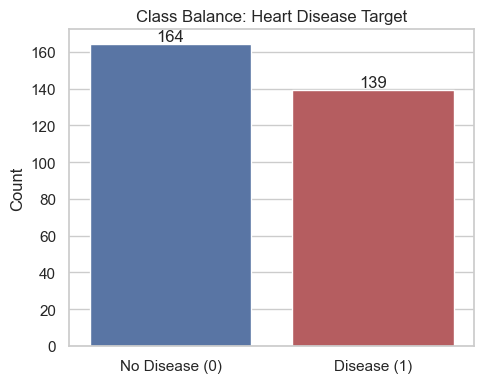

Class balance analysis
----------------------------------------
  No Disease (0): 164 records (54.1%)
  Disease (1)   : 139 records (45.9%)
  Imbalance ratio (majority:minority): 1.18 : 1
  -> Close enough to balanced that accuracy stays meaningful, but we
     still track precision/recall/F1/ROC-AUC as a safety net.
Saved plot -> plots\class_balance.png


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["target"].value_counts().sort_index()
sns.barplot(x=["No Disease (0)", "Disease (1)"], y=counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_title("Class Balance: Heart Disease Target")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "class_balance.png"))
plt.show()

print("Class balance analysis")
print("-" * 40)
print(f"  No Disease (0): {counts[0]} records ({counts[0]/len(df):.1%})")
print(f"  Disease (1)   : {counts[1]} records ({counts[1]/len(df):.1%})")
imbalance_ratio = counts.max() / counts.min()
print(f"  Imbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")
print("  -> Close enough to balanced that accuracy stays meaningful, but we")
print("     still track precision/recall/F1/ROC-AUC as a safety net.")
print(f"Saved plot -> {os.path.join(PLOTS_DIR, 'class_balance.png')}")


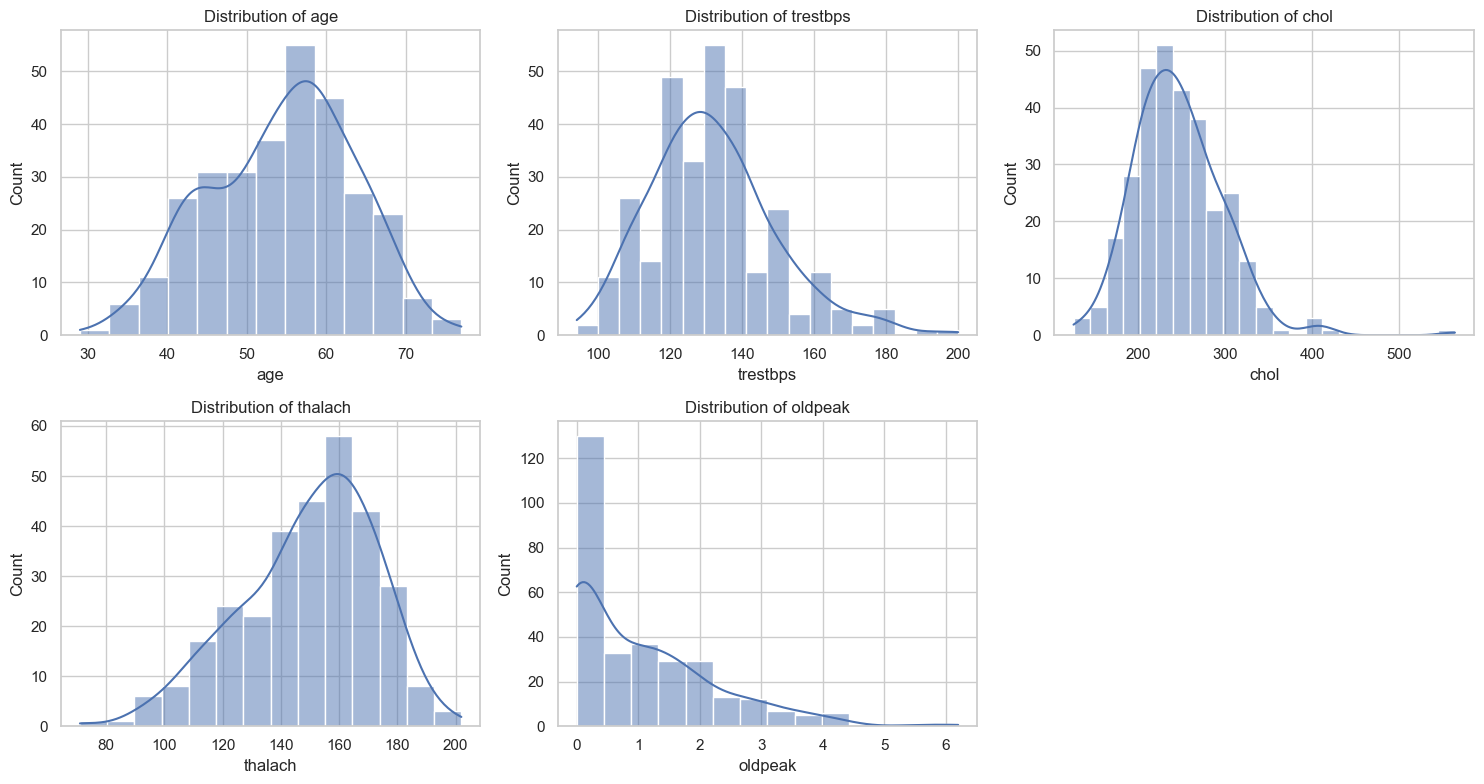

Distribution summary for continuous features
------------------------------------------------------------
Feature        Mean      Std      Min      Max     Skew
age           54.44     9.04    29.00    77.00    -0.21
trestbps     131.69    17.60    94.00   200.00     0.71
chol         246.69    51.78   126.00   564.00     1.14
thalach      149.61    22.88    71.00   202.00    -0.54
oldpeak        1.04     1.16     0.00     6.20     1.27

Skew > 1 or < -1 indicates a noticeably skewed distribution;
oldpeak in particular is heavily right-skewed (zero-inflated).
Saved plot -> plots\histograms.png


In [9]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "histograms.png"))
plt.show()

print("Distribution summary for continuous features")
print("-" * 60)
print(f"{'Feature':10s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s} {'Skew':>8s}")
for col in numeric_cols:
    s = df[col]
    print(f"{col:10s} {s.mean():8.2f} {s.std():8.2f} {s.min():8.2f} {s.max():8.2f} {s.skew():8.2f}")
print()
print("Skew > 1 or < -1 indicates a noticeably skewed distribution;")
print("oldpeak in particular is heavily right-skewed (zero-inflated).")
print(f"Saved plot -> {os.path.join(PLOTS_DIR, 'histograms.png')}")


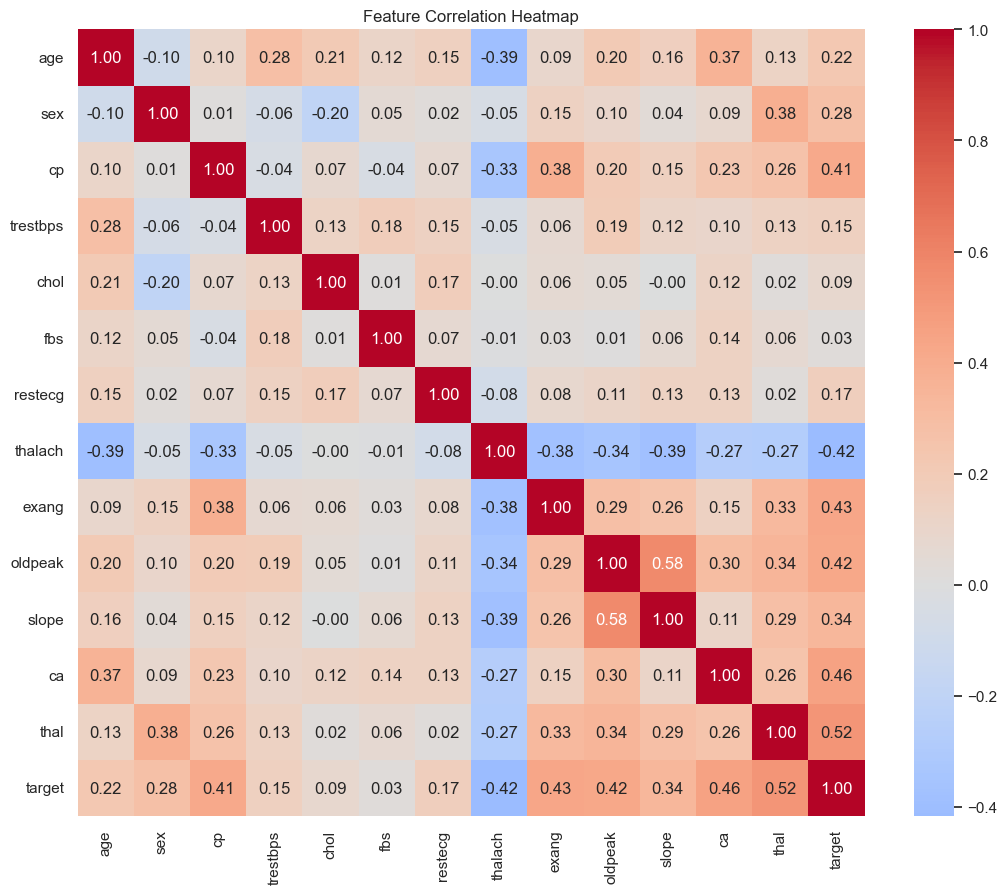

Top features correlated with the target (absolute Pearson correlation)
------------------------------------------------------------
  thal      : +0.522
  ca        : +0.460
  exang     : +0.432
  oldpeak   : +0.425
  thalach   : -0.417
  cp        : +0.414
  slope     : +0.339
  sex       : +0.277
  age       : +0.223
  restecg   : +0.169
  trestbps  : +0.151
  chol      : +0.085
  fbs       : +0.025

Saved plot -> plots\correlation_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "correlation_heatmap.png"))
plt.show()

print("Top features correlated with the target (absolute Pearson correlation)")
print("-" * 60)
target_corr = corr["target"].drop("target").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    signed = corr["target"][feat]
    print(f"  {feat:10s}: {signed:+.3f}")
print(f"\nSaved plot -> {os.path.join(PLOTS_DIR, 'correlation_heatmap.png')}")


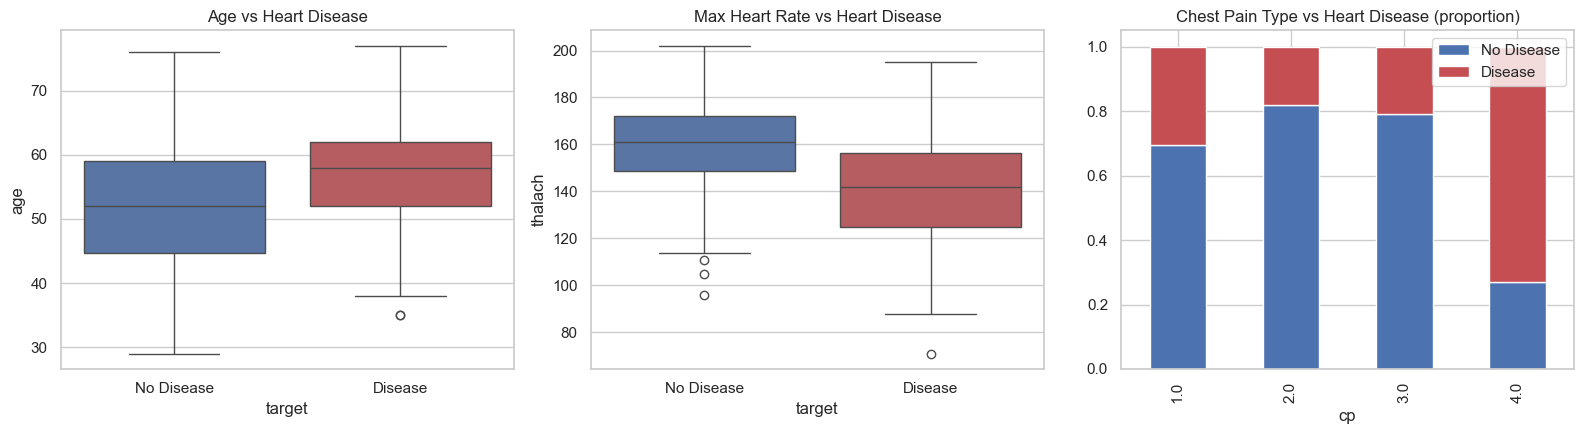

Feature-vs-target group comparisons
------------------------------------------------------------
  Mean age            -> No Disease: 52.6  |  Disease: 56.6
  Mean max heart rate -> No Disease: 158.4  |  Disease: 139.3

  Disease rate by chest pain type (cp):
    cp=1: 30.4% of patients with this chest pain type have disease
    cp=2: 18.0% of patients with this chest pain type have disease
    cp=3: 20.9% of patients with this chest pain type have disease
    cp=4: 72.9% of patients with this chest pain type have disease

Saved plot -> plots\feature_relationships.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=df, x="target", y="age", ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Age vs Heart Disease")
axes[0].set_xticklabels(["No Disease", "Disease"])

sns.boxplot(data=df, x="target", y="thalach", ax=axes[1], palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Max Heart Rate vs Heart Disease")
axes[1].set_xticklabels(["No Disease", "Disease"])

cp_ct = pd.crosstab(df["cp"], df["target"], normalize="index")
cp_ct.plot(kind="bar", stacked=True, ax=axes[2], color=["#4C72B0", "#C44E52"])
axes[2].set_title("Chest Pain Type vs Heart Disease (proportion)")
axes[2].legend(["No Disease", "Disease"])

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "feature_relationships.png"))
plt.show()

print("Feature-vs-target group comparisons")
print("-" * 60)
age_by_target = df.groupby("target")["age"].mean()
thalach_by_target = df.groupby("target")["thalach"].mean()
print(f"  Mean age            -> No Disease: {age_by_target[0]:.1f}  |  Disease: {age_by_target[1]:.1f}")
print(f"  Mean max heart rate -> No Disease: {thalach_by_target[0]:.1f}  |  Disease: {thalach_by_target[1]:.1f}")
print()
print("  Disease rate by chest pain type (cp):")
for cp_val in sorted(df["cp"].unique()):
    rate = df[df["cp"] == cp_val]["target"].mean()
    print(f"    cp={cp_val:.0f}: {rate:.1%} of patients with this chest pain type have disease")
print(f"\nSaved plot -> {os.path.join(PLOTS_DIR, 'feature_relationships.png')}")


**EDA takeaways:**
- The classes are reasonably balanced (~54% / 46%), so accuracy is a meaningful metric here but we still track precision/recall/ROC-AUC to be safe.
- `thalach` (max heart rate) and `oldpeak` (ST depression) show visibly different distributions between classes — likely strong predictors.
- `cp` (chest pain type) is a strong categorical signal — asymptomatic chest pain is associated with a much higher rate of disease, which matches clinical intuition.
- `age`, `trestbps`, and `chol` correlate with the target but more weakly than the exercise-test-derived features.

## 4. Feature Engineering & Model Development

**Feature groups:**
- **Continuous** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) → scaled with `StandardScaler`
- **Nominal categorical** (`cp`, `restecg`, `slope`, `thal`, `ca`) → one-hot encoded with `OneHotEncoder`
- **Binary** (`sex`, `fbs`, `exang`) → passed through as-is

All of this is wrapped in a single `ColumnTransformer` + `Pipeline`, so the exact same preprocessing is guaranteed at inference time — this pipeline object is what we'll serialize for deployment.

We train **two models**: **Random Forest** and **XGBoost**, each tuned with `GridSearchCV` over 5-fold stratified cross-validation, optimizing ROC-AUC.

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Group features by how they need to be preprocessed
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]      # scale
categorical_cols = ["cp", "restecg", "slope", "thal", "ca"]              # one-hot encode
binary_cols = ["sex", "fbs", "exang"]                                    # already 0/1, pass through

print("Feature groups")
print("-" * 40)
print(f"  Continuous  ({len(continuous_cols)}): {continuous_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"  Binary      ({len(binary_cols)}): {binary_cols}")
print(f"  Total input features: {len(continuous_cols) + len(categorical_cols) + len(binary_cols)}")

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print()
print("Train/test split (80/20, stratified on target)")
print("-" * 40)
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"  Train class balance -> {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Test class balance  -> {y_test.value_counts(normalize=True).round(3).to_dict()}")
print("  (stratify=y keeps the same ~54/46 class ratio in both splits)")

# Single preprocessing pipeline: scaling for continuous, one-hot for nominal
# categorical, and binary features passed through unchanged. This is fit
# ONLY on X_train inside GridSearchCV/cross-validation folds -- never on the
# full dataset -- so there's no leakage from the test set into scaling stats.
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_cols),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("binary", "passthrough", binary_cols),
    ]
)
print()
print("ColumnTransformer preprocessor built:")
print(f"  {preprocessor}")


Feature groups
----------------------------------------
  Continuous  (5): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Categorical (5): ['cp', 'restecg', 'slope', 'thal', 'ca']
  Binary      (3): ['sex', 'fbs', 'exang']
  Total input features: 13

Train/test split (80/20, stratified on target)
----------------------------------------
  X_train: (242, 13)   y_train: (242,)
  X_test : (61, 13)   y_test : (61,)
  Train class balance -> {0: 0.541, 1: 0.459}
  Test class balance  -> {0: 0.541, 1: 0.459}
  (stratify=y keeps the same ~54/46 class ratio in both splits)

ColumnTransformer preprocessor built:
  ColumnTransformer(transformers=[('continuous', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['cp', 'restecg', 'slope', 'thal', 'ca']),
  

In [13]:
model_grids = {
    "random_forest": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
        ]),
        # n_estimators: more trees generally stabilizes variance, at a compute cost
        # max_depth: None (unlimited) is included to check whether the extra
        #            flexibility overfits on a dataset this small (303 rows)
        # min_samples_leaf: regularizes against overly specific leaf splits
        "param_grid": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [3, 5, 8, None],
            "clf__min_samples_leaf": [1, 2, 4],
        },
    },
    "xgboost": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
        ]),
        # learning_rate paired with n_estimators is the classic XGBoost tuning
        # axis: lower learning rates need more trees to reach the same fit
        # max_depth kept shallow (3-5) since deeper trees overfit fast on 303 rows
        "param_grid": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [3, 4, 5],
            "clf__learning_rate": [0.01, 0.05, 0.1],
        },
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Hyperparameter search space")
print("-" * 40)
for name, cfg in model_grids.items():
    grid = cfg["param_grid"]
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f"  {name:14s}: {n_combos} hyperparameter combinations x {cv.get_n_splits()} CV folds "
          f"= {n_combos * cv.get_n_splits()} model fits")
    for k, v in grid.items():
        print(f"      {k}: {v}")
print()
print(f"Cross-validation: {cv.get_n_splits()}-fold StratifiedKFold (shuffle=True, random_state={RANDOM_STATE})")
print("Scoring metric for GridSearchCV: roc_auc")


Hyperparameter search space
----------------------------------------
  random_forest : 36 hyperparameter combinations x 5 CV folds = 180 model fits
      clf__n_estimators: [100, 200, 300]
      clf__max_depth: [3, 5, 8, None]
      clf__min_samples_leaf: [1, 2, 4]
  xgboost       : 27 hyperparameter combinations x 5 CV folds = 135 model fits
      clf__n_estimators: [100, 200, 300]
      clf__max_depth: [3, 4, 5]
      clf__learning_rate: [0.01, 0.05, 0.1]

Cross-validation: 5-fold StratifiedKFold (shuffle=True, random_state=42)
Scoring metric for GridSearchCV: roc_auc


Run tuning + evaluation for each model. Results (including cross-validated ROC-AUC, and held-out test metrics) are collected in `results` for the MLflow logging step next.

In [14]:
import time

def evaluate_model(name, pipeline, param_grid, X_train, y_train, X_test, y_test, cv):
    """Run GridSearchCV for one model, refit the best estimator, and evaluate
    it on the held-out test set. Returns everything needed for MLflow logging
    and reporting (fitted model, best params, metrics, predictions, cv_results)."""
    print(f"Starting GridSearchCV for '{name}'...")
    start = time.time()

    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
    )
    grid_search.fit(X_train, y_train)

    elapsed = time.time() - start
    best_pipeline = grid_search.best_estimator_

    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "best_cv_roc_auc": grid_search.best_score_,
    }

    print(f"  GridSearchCV finished in {elapsed:.1f}s "
          f"({len(grid_search.cv_results_['params'])} candidates x {cv.get_n_splits()} folds)")
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Held-out test set metrics:")
    for k, v in metrics.items():
        print(f"    {k:16s}: {v:.4f}")

    return {
        "name": name,
        "model": best_pipeline,
        "best_params": grid_search.best_params_,
        "metrics": metrics,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "cv_results": grid_search.cv_results_,
    }


results = {}
print("=" * 60)
print("MODEL TRAINING & HYPERPARAMETER TUNING")
print("=" * 60)
for name, cfg in model_grids.items():
    print()
    results[name] = evaluate_model(
        name, cfg["pipeline"], cfg["param_grid"], X_train, y_train, X_test, y_test, cv
    )
print()
print("=" * 60)
print("All models trained and evaluated.")
print("=" * 60)


MODEL TRAINING & HYPERPARAMETER TUNING

Starting GridSearchCV for 'random_forest'...
  GridSearchCV finished in 7.9s (36 candidates x 5 folds)
  Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
  Held-out test set metrics:
    accuracy        : 0.8852
    precision       : 0.8387
    recall          : 0.9286
    f1              : 0.8814
    roc_auc         : 0.9470
    best_cv_roc_auc : 0.9014

Starting GridSearchCV for 'xgboost'...
  GridSearchCV finished in 2.1s (27 candidates x 5 folds)
  Best params: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100}
  Held-out test set metrics:
    accuracy        : 0.8689
    precision       : 0.8571
    recall          : 0.8571
    f1              : 0.8571
    roc_auc         : 0.9199
    best_cv_roc_auc : 0.8726

All models trained and evaluated.


In [15]:
results_df = pd.DataFrame({
    name: r["metrics"] for name, r in results.items()
}).T
print("Model comparison table (held-out test set):")
results_df


Model comparison table (held-out test set):


,accuracy,precision,recall,f1,roc_auc,best_cv_roc_auc
random_forest,0.885246,0.838710,0.928571,0.881356,0.946970,0.901419
xgboost,0.868852,0.857143,0.857143,0.857143,0.919913,0.872631


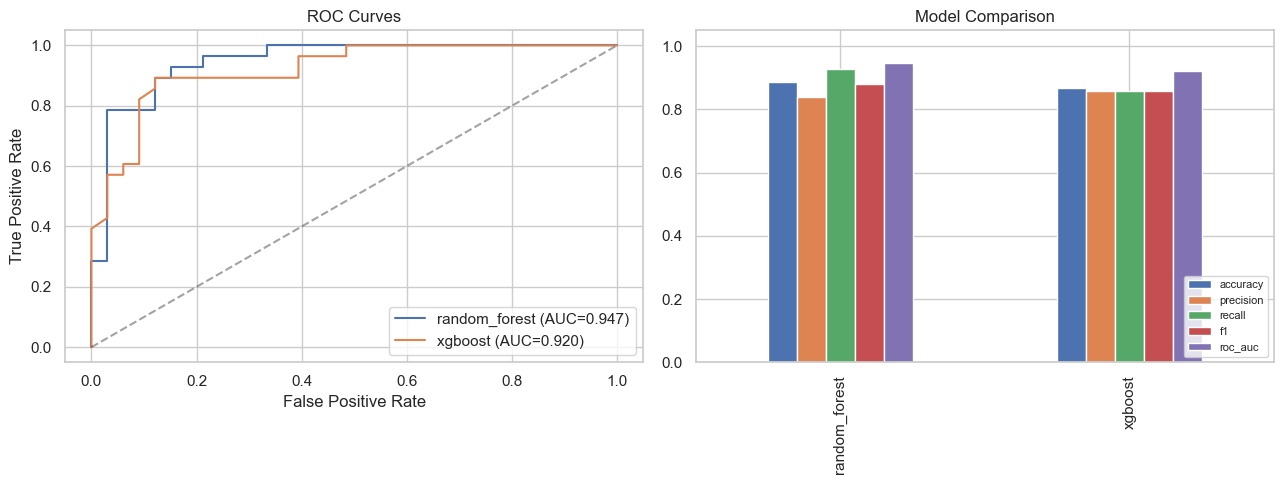

Metric-by-metric winner:
  accuracy  : random_forest (0.8852)
  precision : xgboost (0.8571)
  recall    : random_forest (0.9286)
  f1        : random_forest (0.8814)
  roc_auc   : random_forest (0.9470)

Saved plot -> plots\model_comparison.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['metrics']['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

# Metric comparison bar chart
results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Model Comparison")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison.png"))
plt.show()

print("Metric-by-metric winner:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    winner = results_df[metric].idxmax()
    print(f"  {metric:10s}: {winner} ({results_df.loc[winner, metric]:.4f})")
print(f"\nSaved plot -> {os.path.join(PLOTS_DIR, 'model_comparison.png')}")


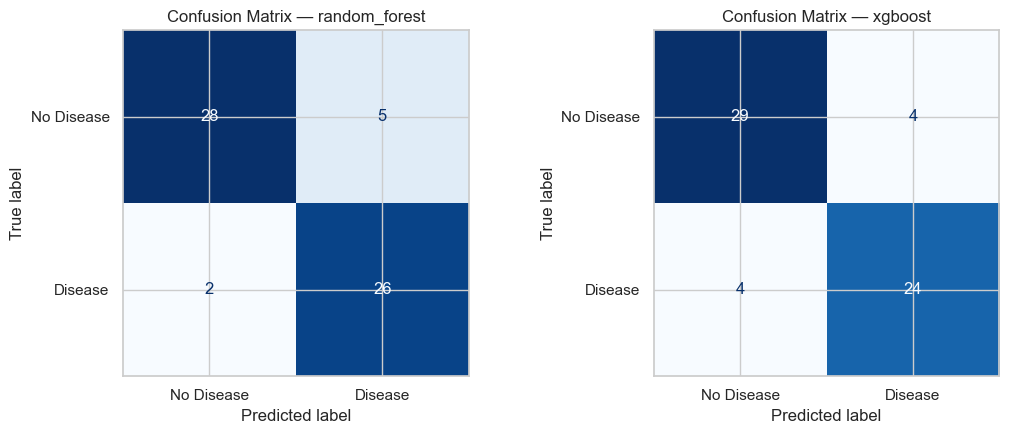

Confusion matrix breakdown
--------------------------------------------------
  random_forest:
    True Negatives (correct 'no disease')  : 28
    False Positives (false alarms)         : 5
    False Negatives (MISSED disease cases) : 2
    True Positives (correctly caught)      : 26
  xgboost:
    True Negatives (correct 'no disease')  : 29
    False Positives (false alarms)         : 4
    False Negatives (MISSED disease cases) : 4
    True Positives (correctly caught)      : 24

Saved plot -> plots\confusion_matrices.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrices.png"))
plt.show()

print("Confusion matrix breakdown")
print("-" * 50)
for name, r in results.items():
    cm = confusion_matrix(y_test, r["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    print(f"  {name}:")
    print(f"    True Negatives (correct 'no disease')  : {tn}")
    print(f"    False Positives (false alarms)         : {fp}")
    print(f"    False Negatives (MISSED disease cases) : {fn}")
    print(f"    True Positives (correctly caught)      : {tp}")
print(f"\nSaved plot -> {os.path.join(PLOTS_DIR, 'confusion_matrices.png')}")


In [18]:
best_model_name = max(results, key=lambda n: results[n]["metrics"]["roc_auc"])
print("=" * 60)
print(f"BEST MODEL SELECTED: {best_model_name}  (ranked by test-set ROC-AUC)")
print("=" * 60)
for k, v in results[best_model_name]["metrics"].items():
    print(f"  {k:16s}: {v:.4f}")
print()
print(f"Best hyperparameters: {results[best_model_name]['best_params']}")


BEST MODEL SELECTED: random_forest  (ranked by test-set ROC-AUC)
  accuracy        : 0.8852
  precision       : 0.8387
  recall          : 0.9286
  f1              : 0.8814
  roc_auc         : 0.9470
  best_cv_roc_auc : 0.9014

Best hyperparameters: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}


## 5. Experiment Tracking with MLflow

Every grid-search run is logged as its own MLflow run: best hyperparameters, all evaluation metrics, the confusion-matrix/ROC plots as artifacts, and the fitted pipeline (preprocessing + model together) as an MLflow model.

Tracking store: a local SQLite database (`mlflow.db`) — inspect results anytime with:
```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```
then open http://127.0.0.1:5000

In [19]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("heart-disease-classification")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow experiment   : heart-disease-classification")
print()

for name, r in results.items():
    with mlflow.start_run(run_name=name):
        run_id = mlflow.active_run().info.run_id
        print(f"--- Logging run for '{name}' (run_id={run_id}) ---")

        # 1) Parameters: best hyperparameters found by GridSearchCV + run context
        mlflow.log_params(r["best_params"])
        mlflow.log_params({"model_type": name, "cv_folds": cv.get_n_splits()})
        print(f"  [1/4] Logged {len(r['best_params']) + 2} parameters")

        # 2) Metrics: all 6 evaluation metrics (accuracy, precision, recall, f1, roc_auc, best_cv_roc_auc)
        for metric_name, value in r["metrics"].items():
            mlflow.log_metric(metric_name, value)
        print(f"  [2/4] Logged {len(r['metrics'])} metrics")

        # 3) Artifacts: confusion matrix + ROC curve plots
        fig, ax = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_test, r["y_pred"])
        ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"Confusion Matrix — {name}")
        cm_path = os.path.join(PLOTS_DIR, f"cm_{name}.png")
        plt.tight_layout()
        plt.savefig(cm_path)
        plt.close(fig)
        mlflow.log_artifact(cm_path, artifact_path="plots")

        fig, ax = plt.subplots(figsize=(5, 4))
        fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
        ax.plot(fpr, tpr, label=f"AUC={r['metrics']['roc_auc']:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(f"ROC Curve — {name}")
        ax.legend()
        roc_path = os.path.join(PLOTS_DIR, f"roc_{name}.png")
        plt.tight_layout()
        plt.savefig(roc_path)
        plt.close(fig)
        mlflow.log_artifact(roc_path, artifact_path="plots")
        print(f"  [3/4] Logged 2 plot artifacts (confusion matrix, ROC curve)")

        # 4) Model: the full pipeline (preprocessing + classifier) as one MLflow model
        mlflow.sklearn.log_model(r["model"], name, serialization_format="cloudpickle")
        print(f"  [4/4] Logged fitted pipeline as MLflow model '{name}'")
        print(f"  Run complete: run_id={run_id}")
        print()

print("All runs logged successfully.")
print(f"Inspect with: mlflow ui --backend-store-uri sqlite:///mlflow.db")


MLflow tracking URI : sqlite:///mlflow.db
MLflow experiment   : heart-disease-classification

--- Logging run for 'random_forest' (run_id=14e01a41bdd94044809facde734c078f) ---
  [1/4] Logged 5 parameters


2026/07/12 21:24:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [2/4] Logged 6 metrics
  [3/4] Logged 2 plot artifacts (confusion matrix, ROC curve)


2026/07/12 21:24:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [4/4] Logged fitted pipeline as MLflow model 'random_forest'
  Run complete: run_id=14e01a41bdd94044809facde734c078f

--- Logging run for 'xgboost' (run_id=d0b3f87c951c47fe9a56262e6f6bcd52) ---
  [1/4] Logged 5 parameters
  [2/4] Logged 6 metrics


2026/07/12 21:24:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 21:24:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [3/4] Logged 2 plot artifacts (confusion matrix, ROC curve)
  [4/4] Logged fitted pipeline as MLflow model 'xgboost'
  Run complete: run_id=d0b3f87c951c47fe9a56262e6f6bcd52

All runs logged successfully.
Inspect with: mlflow ui --backend-store-uri sqlite:///mlflow.db


**MLflow run summary** (params + metrics for every logged run):

In [20]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("heart-disease-classification")
runs = client.search_runs(exp.experiment_id, order_by=["metrics.roc_auc DESC"])

print(f"Experiment ID   : {exp.experiment_id}")
print(f"Experiment name : {exp.name}")
print(f"Total runs found: {len(runs)}")
print()

summary = pd.DataFrame([
    {"run_name": r.data.tags.get("mlflow.runName"), "run_id": r.info.run_id[:8], **r.data.metrics}
    for r in runs
])
print("Runs sorted by ROC-AUC (descending):")
summary


Experiment ID   : 1
Experiment name : heart-disease-classification
Total runs found: 4

Runs sorted by ROC-AUC (descending):


,run_name,run_id,accuracy,precision,recall,f1,roc_auc,best_cv_roc_auc
0,random_forest,14e01a41,0.885246,0.838710,0.928571,0.881356,0.946970,0.901419
1,random_forest,15cb7077,0.885246,0.838710,0.928571,0.881356,0.946970,0.901419
2,xgboost,d0b3f87c,0.868852,0.857143,0.857143,0.857143,0.919913,0.872631
3,xgboost,0c0329a0,0.868852,0.857143,0.857143,0.857143,0.919913,0.872631


## 6. Model Packaging & Reproducibility

We save:
- The **best pipeline** (preprocessing + tuned model, one object) via `joblib` — this is what the FastAPI serving layer loads
- A `model_metadata.json` describing the chosen model, its metrics, and feature schema
- `requirements.txt` capturing exact package versions for a clean, reproducible environment

Because preprocessing lives *inside* the pipeline, there is no risk of train/serve skew — the API only ever calls `pipeline.predict()` on raw feature dictionaries.

In [21]:
import joblib
import json
from datetime import datetime, timezone

best_pipeline = results[best_model_name]["model"]
model_path = os.path.join(MODEL_DIR, "heart_disease_model.joblib")
joblib.dump(best_pipeline, model_path)

file_size_kb = os.path.getsize(model_path) / 1024
print(f"Saved pipeline -> {model_path}  ({file_size_kb:.1f} KB)")
print(f"Model type saved: {best_model_name}")
print()

metadata = {
    "model_name": best_model_name,
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "best_params": results[best_model_name]["best_params"],
    "metrics": results[best_model_name]["metrics"],
    "feature_columns": X.columns.tolist(),
    "continuous_cols": continuous_cols,
    "categorical_cols": categorical_cols,
    "binary_cols": binary_cols,
    "target_mapping": {"0": "no heart disease", "1": "heart disease present"},
}
metadata_path = os.path.join(MODEL_DIR, "model_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved metadata -> {metadata_path}")
print(f"  model_name       : {metadata['model_name']}")
print(f"  trained_at_utc   : {metadata['trained_at_utc']}")
print(f"  feature_columns  : {len(metadata['feature_columns'])} features")
print(f"  metrics logged   : {list(metadata['metrics'].keys())}")
print()
print("Full metadata contents:")
print(json.dumps(metadata, indent=2))


Saved pipeline -> models\heart_disease_model.joblib  (722.0 KB)
Model type saved: random_forest

Saved metadata -> models\model_metadata.json
  model_name       : random_forest
  trained_at_utc   : 2026-07-12T15:55:13.556410+00:00
  feature_columns  : 13 features
  metrics logged   : ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'best_cv_roc_auc']

Full metadata contents:
{
  "model_name": "random_forest",
  "trained_at_utc": "2026-07-12T15:55:13.556410+00:00",
  "best_params": {
    "clf__max_depth": 5,
    "clf__min_samples_leaf": 2,
    "clf__n_estimators": 200
  },
  "metrics": {
    "accuracy": 0.8852459016393442,
    "precision": 0.8387096774193549,
    "recall": 0.9285714285714286,
    "f1": 0.8813559322033898,
    "roc_auc": 0.946969696969697,
    "best_cv_roc_auc": 0.9014188709840883
  },
  "feature_columns": [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal

In [22]:
# Sanity check: reload the saved pipeline from disk and confirm predictions
# match the in-memory model bit-for-bit. This is the kind of check that
# would immediately catch a broken/incomplete serialization.
print("Running reload sanity check...")
reloaded = joblib.load(model_path)
print(f"  Reloaded object type: {type(reloaded).__name__}")

sample = X_test.iloc[[0]]
original_pred = best_pipeline.predict_proba(sample)[0, 1]
reloaded_pred = reloaded.predict_proba(sample)[0, 1]

print(f"  Original model prediction (P[disease]): {original_pred:.6f}")
print(f"  Reloaded model prediction (P[disease]): {reloaded_pred:.6f}")

assert np.isclose(original_pred, reloaded_pred), "Reloaded model prediction mismatch!"
print("  MATCH -- reload sanity check PASSED.")
print(f"\nReload check OK — probability of disease for sample row: {reloaded_pred:.4f}")


Running reload sanity check...
  Reloaded object type: Pipeline
  Original model prediction (P[disease]): 0.238132
  Reloaded model prediction (P[disease]): 0.238132
  MATCH -- reload sanity check PASSED.

Reload check OK — probability of disease for sample row: 0.2381


In [23]:
requirements = """pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
xgboost==2.1.1
mlflow==2.16.0
matplotlib==3.9.1
seaborn==0.13.2
joblib==1.4.2
ucimlrepo==0.0.7
fastapi==0.112.0
uvicorn==0.30.5
pydantic==2.8.2
pytest==8.3.2
"""
req_path = "requirements.txt"
with open(req_path, "w") as f:
    f.write(requirements)

n_packages = len([l for l in requirements.strip().splitlines() if l.strip()])
print(f"Saved {req_path} with {n_packages} pinned packages:")
print(requirements)


Saved requirements.txt with 13 pinned packages:
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
xgboost==2.1.1
mlflow==2.16.0
matplotlib==3.9.1
seaborn==0.13.2
joblib==1.4.2
ucimlrepo==0.0.7
fastapi==0.112.0
uvicorn==0.30.5
pydantic==2.8.2
pytest==8.3.2



## 7. Notebook Run Summary

In [24]:
print("=" * 60)
print("NOTEBOOK RUN SUMMARY")
print("=" * 60)
print(f"Dataset          : {df.shape[0]} rows x {df.shape[1]} columns (UCI Heart Disease, Cleveland)")
print(f"Missing values   : imputed with median in 'ca' and 'thal'")
print(f"Class balance    : {(df['target']==0).sum()} no-disease / {(df['target']==1).sum()} disease")
print(f"Train/test split : {X_train.shape[0]} / {X_test.shape[0]} rows (80/20, stratified)")
print(f"Models trained   : {list(results.keys())}")
print(f"Best model       : {best_model_name}  (ROC-AUC = {results[best_model_name]['metrics']['roc_auc']:.4f})")
print(f"MLflow runs      : {len(results)} runs logged to sqlite:///mlflow.db")
print(f"Saved artifacts  :")
print(f"  - {model_path}")
print(f"  - {metadata_path}")
print(f"  - {req_path}")
print(f"  - {clean_path}")
print(f"  - {len(os.listdir(PLOTS_DIR))} plots in {PLOTS_DIR}/")
print("=" * 60)
print("Tasks 1-4 complete.")
print("=" * 60)


NOTEBOOK RUN SUMMARY
Dataset          : 303 rows x 14 columns (UCI Heart Disease, Cleveland)
Missing values   : imputed with median in 'ca' and 'thal'
Class balance    : 164 no-disease / 139 disease
Train/test split : 242 / 61 rows (80/20, stratified)
Models trained   : ['random_forest', 'xgboost']
Best model       : random_forest  (ROC-AUC = 0.9470)
MLflow runs      : 2 runs logged to sqlite:///mlflow.db
Saved artifacts  :
  - models\heart_disease_model.joblib
  - models\model_metadata.json
  - requirements.txt
  - data\heart_disease_clean.csv
  - 10 plots in plots/
Tasks 1-4 complete.


## Next steps (outside this notebook)

This notebook satisfies **Tasks 1–4** of the assignment (EDA, feature engineering & modeling, MLflow tracking, model packaging). The remaining tasks build on the artifacts produced here:

| Task | Uses |
|---|---|
| 5. CI/CD Pipeline | `requirements.txt`, `tests/` (pytest on preprocessing + model) |
| 6. Containerization | `models/heart_disease_model.joblib`, a FastAPI `/predict` app |
| 7. Deployment | Docker image → Minikube/Docker Desktop Kubernetes manifests |
| 8. Monitoring | API request logging, Prometheus/Grafana on top of the FastAPI service |
| 9. Report | This notebook's plots (`plots/`) + MLflow run screenshots + architecture diagram |
